In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.metrics import silhouette_score
import joblib

In [2]:
DATA_PATH = '../../data/Mall_Customers.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


1. Basic Preprocessing

In [3]:
df.drop(columns='CustomerID', inplace=True)

In [4]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [5]:
X = df.values

2. Train / Test Split (for template purposes)

In [6]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

3. Scaling

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

4. Model Candidates

In [8]:
models = {
    "KMeans": KMeans(n_clusters=4, random_state=42, n_init=10),
    "Agglomerative": AgglomerativeClustering(n_clusters=4),
    "DBSCAN": DBSCAN(eps=0.7, min_samples=5)
}

results = {}

5. Train and Evaluate

In [9]:
for name, model in models.items():
    labels = model.fit_predict(X_train)

    # Skip DBSCAN if 1 cluster
    if len(set(labels)) <= 1:
        score = -1
    else:
        score = silhouette_score(X_train, labels)
    
    results[name] = score

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

# Fit best model fully
train_labels = best_model.fit_predict(X_train)

6. Visualization

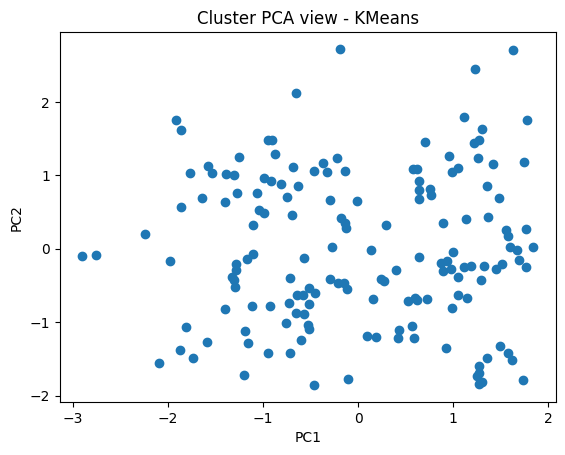

In [10]:
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_train)

plt.figure()
plt.scatter(X_vis[:, 0], X_vis[:, 1])
plt.title(f"Cluster PCA view - {best_model_name}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [11]:
joblib.dump(best_model, "../../models/clustering_model.pkl")
best_model_name, results

('KMeans',
 {'KMeans': 0.3003154184672217,
  'Agglomerative': 0.26853371549926086,
  'DBSCAN': 0.1309786516618994})